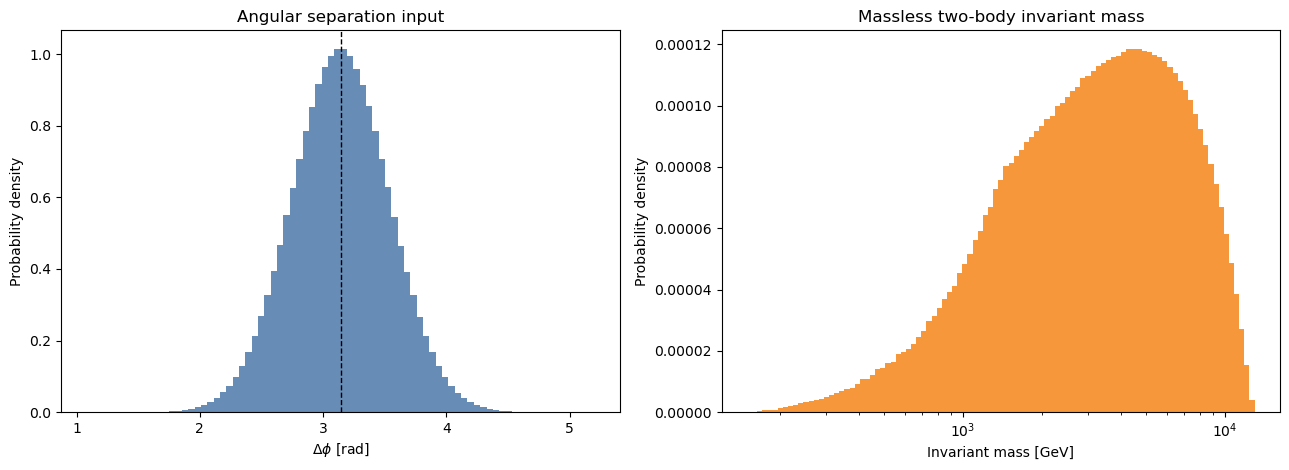

Events: 5,000,000
pT range: [80, 6500] GeV
Delta-phi model: N(180.0 deg, 10.0 deg), truncated to [0, 180] deg
Mean mass:   5793.4 GeV
Median mass: 5613.2 GeV
16-84% band: [2664.3, 8983.7] GeV


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Interpret "180 degrees of separation" as approximately back-to-back in azimuth.
# With Δη = 0, the massless two-body invariant mass reduces to:
# m = sqrt(2 pT1 pT2 (1 - cos(Δφ))).

rng = np.random.default_rng(7)

n_events = 5_000_000
pt_min = 80.0
pt_max = 13_000 / 2
mean_delta_phi_deg = 180.0
mean_delta_phi_rad = np.pi
sigma_delta_phi_rad = np.pi / 8
# sigma_delta_phi_deg = 10.0

def sample_delta_phi(size, mean_rad, sigma_rad, rng):
    samples = np.empty(size)
    filled = 0

    while filled < size:
        trial = rng.normal(mean_rad, sigma_rad, size=max(1024, 2 * (size - filled)))
        accepted = trial[(trial >= 0.0) & (trial <= np.pi)]
        take = min(size - filled, accepted.size)
        samples[filled:filled + take] = accepted[:take]
        filled += take

    return samples

pt1 = rng.uniform(pt_min, pt_max, size=n_events)
pt2 = rng.uniform(pt_min, pt_max, size=n_events)
# pt1 = rng.exponential(scale=200.0, size=n_events) + pt_min
# pt2 = rng.exponential(scale=200.0, size=n_events) + pt_min
# delta_phi = sample_delta_phi(n_events, mean_delta_phi_rad, sigma_delta_phi_rad, rng)
delta_phi = rng.normal(mean_delta_phi_rad, sigma_delta_phi_rad, size=n_events)
# delta_phi = rng.uniform(0.0, 2*np.pi, size=n_events)
mass = np.sqrt(2.0 * pt1 * pt2 * (1.0 - np.cos(delta_phi)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].hist(delta_phi, bins=80, density=True, color="#4C78A8", alpha=0.85)
axes[0].axvline(mean_delta_phi_rad, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel(r"$\Delta\phi$ [rad]")
axes[0].set_ylabel("Probability density")
axes[0].set_title("Angular separation input")

mass_bins = np.geomspace(mass.min(), mass.max(), 100)
axes[1].hist(mass, bins=mass_bins, density=True, color="#F58518", alpha=0.85)
axes[1].set_xscale("log")
axes[1].set_xlabel("Invariant mass [GeV]")
axes[1].set_ylabel("Probability density")
axes[1].set_title("Massless two-body invariant mass")

plt.tight_layout()
plt.show()

quantiles = np.quantile(mass, [0.16, 0.5, 0.84])
print(f"Events: {n_events:,}")
print(f"pT range: [{pt_min:.0f}, {pt_max:.0f}] GeV")
print(f"Delta-phi model: N({mean_delta_phi_deg:.1f} deg, {np.rad2deg(sigma_delta_phi_rad):.1f} deg), truncated to [0, 180] deg")
print(f"Mean mass:   {mass.mean():.1f} GeV")
print(f"Median mass: {quantiles[1]:.1f} GeV")
print(f"16-84% band: [{quantiles[0]:.1f}, {quantiles[2]:.1f}] GeV")

# Other stuff

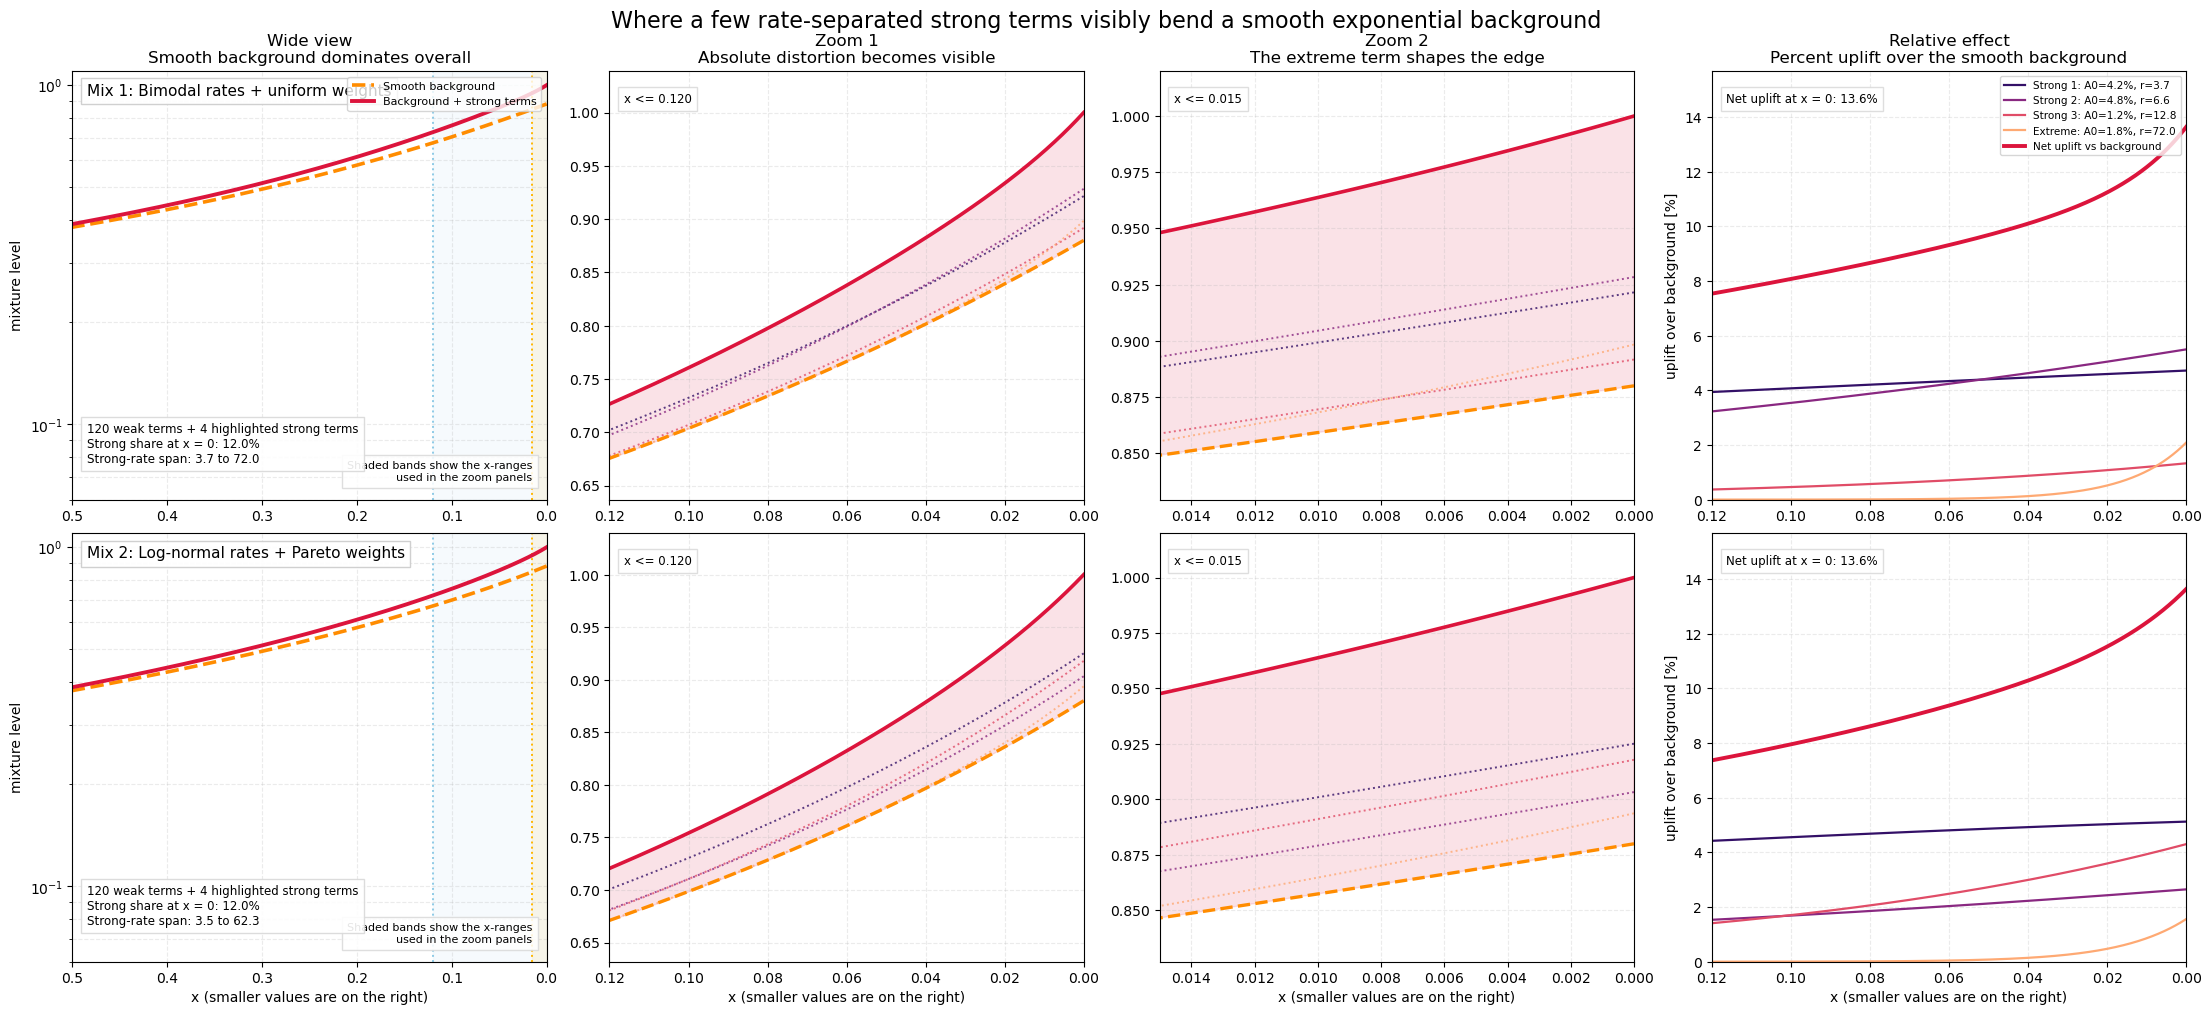

In [6]:
import numpy as np
import matplotlib.pyplot as plt

X_GRID = np.linspace(0.0, 0.5, 4000)
N_BASE_EXPS = 120
N_STRONG_EXPS = 4
STRONG_TOTAL_WEIGHT = 0.12
DEFAULT_BASE_DISTRIBUTION = "bimodal_uniform"
ZOOM_LIMITS = (0.12, 0.015)
OVERVIEW_COMPONENT_STRIDE = 10
ZOOM_GUIDES = [
    {"x_max": ZOOM_LIMITS[0], "color": "#8ecae6", "label": "Zoom 1 region"},
    {"x_max": ZOOM_LIMITS[1], "color": "#ffb703", "label": "Zoom 2 region"},
]

def sample_bimodal_uniform(rng, size):
    slow = rng.normal(0.6, 0.12, size // 2)
    fast = rng.normal(4.2, 0.6, size - size // 2)
    rates = np.concatenate([slow, fast])
    weights = rng.uniform(0.2, 1.6, size)
    return rates, weights

def sample_lognormal_pareto(rng, size):
    rates = rng.lognormal(0.45, 0.85, size)
    weights = 0.05 + rng.pareto(2.2, size)
    return rates, weights

def sample_gamma_lognormal(rng, size):
    rates = rng.gamma(shape=2.3, scale=0.9, size=size)
    weights = rng.lognormal(mean=-0.15, sigma=0.7, size=size)
    return rates, weights

BASE_DISTRIBUTION_OPTIONS = [
    ("bimodal_uniform", "Bimodal rates + uniform weights", sample_bimodal_uniform),
    ("lognormal_pareto", "Log-normal rates + Pareto weights", sample_lognormal_pareto),
    ("gamma_lognormal", "Gamma rates + log-normal weights", sample_gamma_lognormal),
]
BASE_DISTRIBUTION_MAP = {
    name: {"label": label, "sampler": sampler}
    for name, label, sampler in BASE_DISTRIBUTION_OPTIONS
}

def list_base_distributions():
    return [(name, meta["label"]) for name, meta in BASE_DISTRIBUTION_MAP.items()]

def spaced_strong_rates(rng, size):
    if size == 1:
        return np.array([rng.uniform(55.0, 80.0)])

    rates = np.geomspace(3.5, 22.0, size)
    rates[:-1] *= rng.uniform(0.92, 1.08, size - 1)
    rates[-1] = rng.uniform(55.0, 80.0)
    return np.sort(rates)

def balanced_strong_weights(rng, size):
    raw = rng.dirichlet(np.linspace(2.6, 1.2, size))
    raw = 0.65 * raw + 0.35 / size
    return raw / raw.sum()

def strong_label(strong_rates, strong_components, idx):
    amplitude_pct = 100.0 * strong_components[idx, 0]
    if idx == len(strong_rates) - 1:
        prefix = "Extreme"
    else:
        prefix = f"Strong {idx + 1}"
    return f"{prefix}: A0={amplitude_pct:.1f}%, r={strong_rates[idx]:.1f}"

def resolve_distribution_names(base_distribution, other_distributions=None):
    names = [base_distribution]

    if other_distributions is None:
        extras = []
    elif isinstance(other_distributions, str):
        extras = [other_distributions]
    else:
        extras = list(other_distributions)
    names.extend(extras)

    resolved = []
    seen = set()
    for name in names:
        if name not in BASE_DISTRIBUTION_MAP:
            valid_names = ", ".join(BASE_DISTRIBUTION_MAP)
            raise ValueError(f"Unknown base distribution '{name}'. Choose from: {valid_names}")
        if name not in seen:
            resolved.append(name)
            seen.add(name)
    return resolved

def make_mixture(distribution_name, seed, x_grid=X_GRID):
    rng = np.random.default_rng(seed)
    meta = BASE_DISTRIBUTION_MAP[distribution_name]

    base_rates, base_weights = meta["sampler"](rng, N_BASE_EXPS)
    base_rates = np.clip(base_rates, 0.03, None)
    base_weights = np.clip(base_weights, 1e-6, None)
    base_weights = base_weights / base_weights.sum() * (1.0 - STRONG_TOTAL_WEIGHT)

    strong_rates = spaced_strong_rates(rng, N_STRONG_EXPS)
    strong_weights = balanced_strong_weights(rng, N_STRONG_EXPS) * STRONG_TOTAL_WEIGHT

    base_components = base_weights[:, None] * np.exp(-base_rates[:, None] * x_grid[None, :])
    strong_components = strong_weights[:, None] * np.exp(-strong_rates[:, None] * x_grid[None, :])
    base_sum = base_components.sum(axis=0)
    strong_sum = strong_components.sum(axis=0)

    return {
        "label": meta["label"],
        "base_components": base_components,
        "strong_components": strong_components,
        "base_sum": base_sum,
        "strong_sum": strong_sum,
        "strong_rates": strong_rates,
        "total_sum": base_sum + strong_sum,
    }

def mixture_summary_text(mixture):
    strong_share_pct = 100.0 * mixture["strong_sum"][0]
    rate_min = mixture["strong_rates"][0]
    rate_max = mixture["strong_rates"][-1]
    return "\n".join([
        f"{N_BASE_EXPS} weak terms + {N_STRONG_EXPS} highlighted strong terms",
        f"Strong share at x = 0: {strong_share_pct:.1f}%",
        f"Strong-rate span: {rate_min:.1f} to {rate_max:.1f}",
    ])

def add_zoom_guides(ax):
    for guide in ZOOM_GUIDES:
        ax.axvspan(0.0, guide["x_max"], color=guide["color"], alpha=0.08, zorder=0)
        ax.axvline(guide["x_max"], color=guide["color"], linestyle=":", linewidth=1.4)
    ax.text(
        0.97,
        0.04,
        "Shaded bands show the x-ranges\nused in the zoom panels",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="0.85"),
    )

def plot_zoom_panel(ax, x_grid, base_sum, total_sum, strong_components, strong_colors, x_max):
    mask = x_grid <= x_max
    local_base = base_sum[mask]
    local_total = total_sum[mask]
    y_min = min(local_base.min(), local_total.min())
    y_max = max(local_base.max(), local_total.max())
    y_pad = max(0.02, 0.12 * (y_max - y_min))

    for idx, component in enumerate(strong_components):
        ax.plot(
            x_grid,
            base_sum + component,
            color=strong_colors[idx],
            linewidth=1.4,
            linestyle=":",
            alpha=0.8,
        )
    ax.fill_between(x_grid, base_sum, total_sum, color="crimson", alpha=0.12)
    ax.plot(x_grid, base_sum, color="darkorange", linewidth=2.4, linestyle="--")
    ax.plot(x_grid, total_sum, color="crimson", linewidth=2.6)
    ax.set_xlim(x_max, 0.0)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.grid(True, ls="--", alpha=0.25)
    ax.text(
        0.03,
        0.95,
        f"x <= {x_max:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.5,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="0.85"),
    )

def plot_relative_panel(ax, mixture, x_grid, strong_colors, row_number):
    strong_components = mixture["strong_components"]
    strong_rates = mixture["strong_rates"]
    base_sum = mixture["base_sum"]
    strong_sum = mixture["strong_sum"]

    relative_components = 100.0 * strong_components / base_sum
    relative_total = 100.0 * strong_sum / base_sum

    for idx, component in enumerate(relative_components):
        ax.plot(
            x_grid,
            component,
            color=strong_colors[idx],
            linewidth=1.6,
            label=strong_label(strong_rates, strong_components, idx) if row_number == 1 else None,
        )
    ax.plot(
        x_grid,
        relative_total,
        color="crimson",
        linewidth=2.8,
        label="Net uplift vs background" if row_number == 1 else None,
    )
    ax.set_xlim(0.12, 0.0)
    ax.set_ylim(0.0, max(1.0, relative_total[x_grid <= 0.12].max() * 1.15))
    ax.grid(True, ls="--", alpha=0.25)
    ax.text(
        0.03,
        0.95,
        f"Net uplift at x = 0: {relative_total[0]:.1f}%",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.5,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="0.85"),
    )

def plot_mixture_row(ax_row, mixture, x_grid, strong_colors, row_number):
    overview_ax, zoom1_ax, zoom2_ax, relative_ax = ax_row
    base_components = mixture["base_components"]
    strong_components = mixture["strong_components"]
    base_sum = mixture["base_sum"]
    total_sum = mixture["total_sum"]

    add_zoom_guides(overview_ax)
    for component in base_components[::OVERVIEW_COMPONENT_STRIDE]:
        overview_ax.plot(x_grid, np.clip(component, 1e-5, None), color="0.75", alpha=0.14, linewidth=0.8)
    for idx, component in enumerate(strong_components):
        overview_ax.plot(
            x_grid,
            np.clip(component, 1e-5, None),
            color=strong_colors[idx],
            linewidth=1.3,
            alpha=0.85,
        )
    overview_ax.plot(
        x_grid,
        base_sum,
        color="darkorange",
        linewidth=2.6,
        linestyle="--",
        label="Smooth background" if row_number == 1 else None,
    )
    overview_ax.plot(
        x_grid,
        total_sum,
        color="crimson",
        linewidth=2.8,
        label="Background + strong terms" if row_number == 1 else None,
    )
    overview_ax.set_yscale("log")
    overview_ax.set_xlim(0.5, 0.0)
    overview_ax.set_ylim(0.06, 1.1)
    overview_ax.grid(True, which="both", ls="--", alpha=0.25)
    overview_ax.text(
        0.03,
        0.97,
        f"Mix {row_number}: {mixture['label']}",
        transform=overview_ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        bbox=dict(facecolor="white", alpha=0.92, edgecolor="0.8"),
    )
    overview_ax.text(
        0.03,
        0.08,
        mixture_summary_text(mixture),
        transform=overview_ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=8.5,
        bbox=dict(facecolor="white", alpha=0.9, edgecolor="0.85"),
    )

    plot_zoom_panel(zoom1_ax, x_grid, base_sum, total_sum, strong_components, strong_colors, ZOOM_LIMITS[0])
    plot_zoom_panel(zoom2_ax, x_grid, base_sum, total_sum, strong_components, strong_colors, ZOOM_LIMITS[1])
    plot_relative_panel(relative_ax, mixture, x_grid, strong_colors, row_number)

def plot_zoom_progression(
    base_distribution=DEFAULT_BASE_DISTRIBUTION,
    other_distributions=None,
    seeds=None,
    save_path="mixture_zoom_progression.png",
    x_grid=X_GRID,
):
    distribution_names = resolve_distribution_names(base_distribution, other_distributions)

    if seeds is None:
        seeds = [101 + 101 * idx for idx in range(len(distribution_names))]
    elif len(seeds) != len(distribution_names):
        raise ValueError("Number of seeds must match the number of selected base distributions")

    mixtures = [
        make_mixture(distribution_name, seed, x_grid=x_grid)
        for distribution_name, seed in zip(distribution_names, seeds)
    ]
    strong_colors = plt.cm.magma(np.linspace(0.18, 0.82, N_STRONG_EXPS))

    fig, axes = plt.subplots(
        len(mixtures),
        4,
        figsize=(22, 4.9 * len(mixtures)),
        squeeze=False,
        constrained_layout=True,
    )
    fig.suptitle(
        "Where a few rate-separated strong terms visibly bend a smooth exponential background",
        fontsize=16,
        y=1.02,
    )

    column_titles = [
        "Wide view\nSmooth background dominates overall",
        "Zoom 1\nAbsolute distortion becomes visible",
        "Zoom 2\nThe extreme term shapes the edge",
        "Relative effect\nPercent uplift over the smooth background",
    ]
    for col, title in enumerate(column_titles):
        axes[0, col].set_title(title, fontsize=12)

    for row_number, mixture in enumerate(mixtures, start=1):
        plot_mixture_row(axes[row_number - 1], mixture, x_grid, strong_colors, row_number)

    for ax in axes[-1, :]:
        ax.set_xlabel("x (smaller values are on the right)")

    for row_axes in axes:
        row_axes[0].set_ylabel("mixture level")
        row_axes[3].set_ylabel("uplift over background [%]")

    axes[0, 0].legend(loc="upper right", fontsize=8)
    axes[0, 3].legend(loc="upper right", fontsize=7.5)

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return mixtures

mixtures = plot_zoom_progression(other_distributions=["lognormal_pareto"])

# Some other stuff

In [ ]:
 # Exponential mixture (2 components) with interactive sliders
# f(x) = w * λ1 * exp(-λ1 x) + (1 - w) * λ2 * exp(-λ2 x)

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

def plot_mixture(w: float, lam1: float, lam2: float):
    # Pick an x-range that adapts to the slower-decaying component
    lam_min = max(min(lam1, lam2), 1e-6)
    x_max = 10.0 / lam_min  # ~10 e-folds of the slowest component
    x = np.linspace(0.0, 5, 800)

    # Components (each is a proper exponential PDF on [0, ∞))
    f1 = lam1 * np.exp(-lam1 * x)
    f2 = lam2 * np.exp(-lam2 * x)

    # Mixture
    f = w * f1 + (1.0 - w) * f2

    # Plot
    plt.figure(figsize=(7.5, 4.5))
    plt.plot(x, f1, label=r"Component 1: $\lambda_1$ = %.3g" % lam1, linewidth=2)
    plt.plot(x, f2, label=r"Component 2: $\lambda_2$ = %.3g" % lam2, linewidth=2)
    plt.plot(x, f,  label=r"Mixture: $w\,\lambda_1 e^{-\lambda_1 x} + (1-w)\,\lambda_2 e^{-\lambda_2 x}$", linewidth=2)

    plt.xlabel("x")
    plt.ylabel("density")
    plt.title(r"Two-Component Exponential Mixture  (weight $w$ = %.2f)" % w)
    plt.grid(True, alpha=0.3)
    plt.ylim(1e-3, 2.5)
    plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Sliders:
# - w in [0,1]
# - λ1, λ2 on a log slider for convenient exploration over orders of magnitude
w_slider = widgets.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.01, readout_format=".2f", description="w")
lam1_slider = widgets.FloatLogSlider(value=1.0, base=10, min=-2, max=2, step=0.01, description="λ1")
lam2_slider = widgets.FloatLogSlider(value=0.2, base=10, min=-2, max=2, step=0.01, description="λ2")

interact(plot_mixture, w=w_slider, lam1=lam1_slider, lam2=lam2_slider);


interactive(children=(FloatSlider(value=0.5, description='w', max=1.0, step=0.01), FloatLogSlider(value=1.0, d…

# Background Flexibility Proof of Concept

In [2]:
import sys
sys.path.append("/project01/ndcms/atownse2/ExponentialMixtureModel")

import ROOT
import emm

import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Get data
data_tree = emm.get_data(sort_and_index=True, tree=True)

x = ROOT.RooRealVar("x", "Diphoton Mass [GeV]", 500, 4000)
# index=ROOT.RooRealVar("index", "index", 0, 0, 1e6)

data = ROOT.RooDataSet("mgg", "mgg", ROOT.RooArgSet(x), ROOT.RooFit.Import(data_tree))

Loaded 5036 diphoton invariant masses from data.


[#1] INFO:NumericIntegration -- RooRealIntegral::init(Dijet_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_2_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_3_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const o

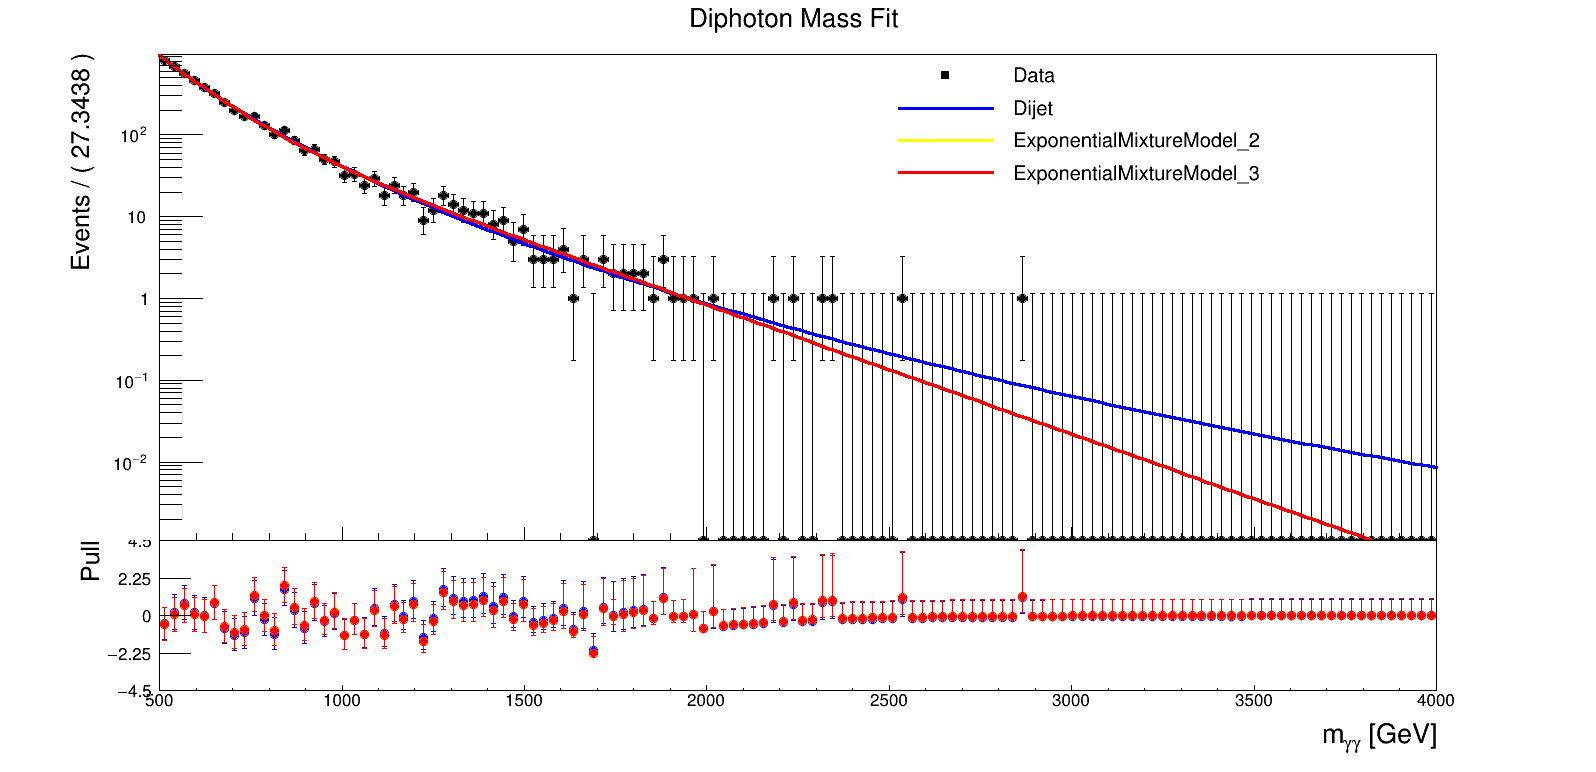

In [15]:
# Plot fits of varying complexity to the signal + background data
models = [emm.Dijet(x)]
models += [emm.ExponentialMixtureModel(x, k, data_mean=data.mean(x)) for k in range(2, 4)]
model_labels = [m.name for m in models]
for m in models:
    m.pdf.fitTo(data, PrintLevel=-1)

emm.plot_fits(data, x, models, model_labels, logx=False)

Data entries (with tail events): 5040
[#1] INFO:NumericIntegration -- RooRealIntegral::init(Dijet_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_2_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_3_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::

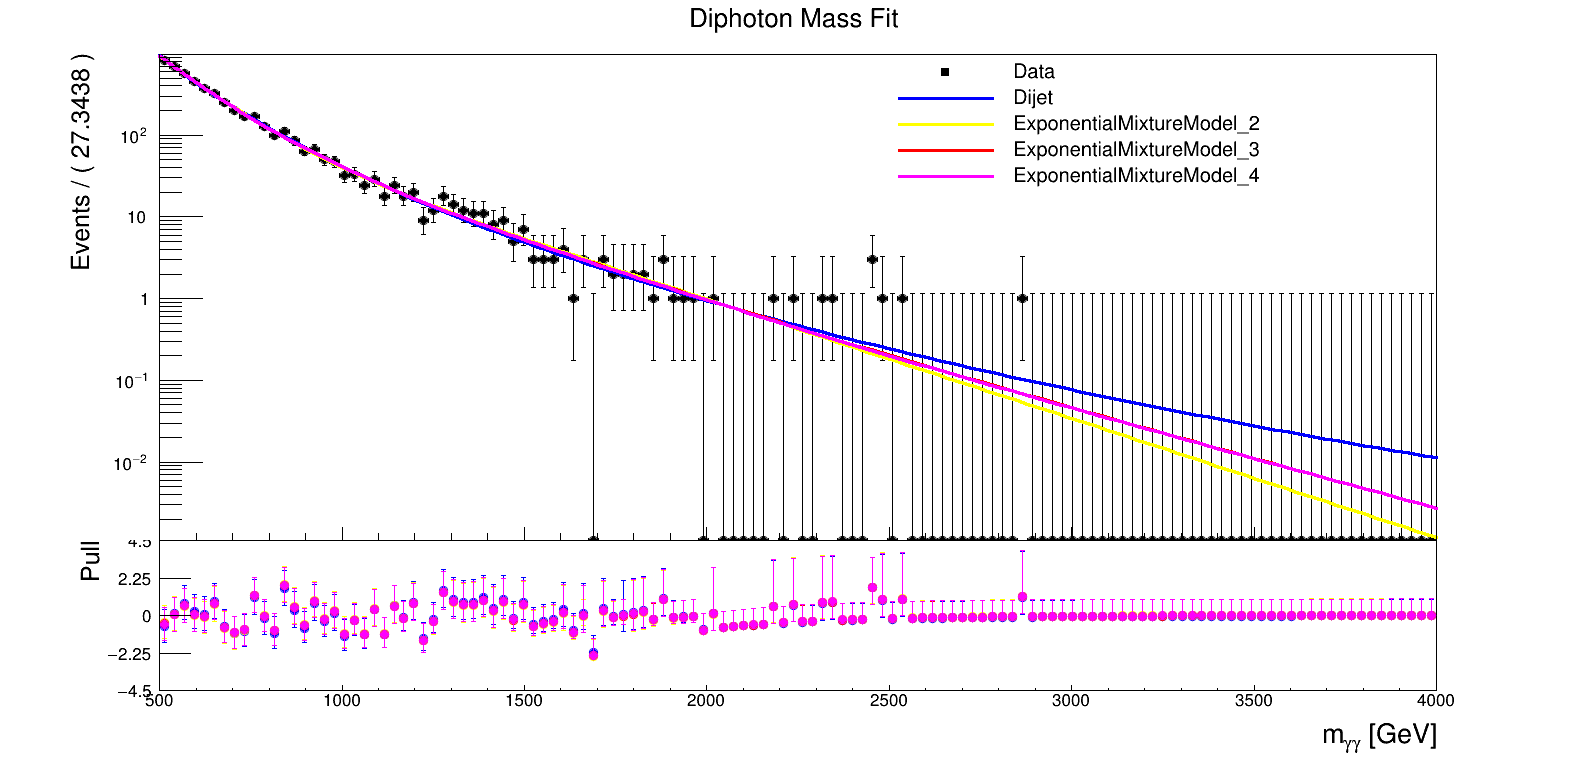

In [27]:
# Add signal to tail
m = 2500
s = 40
n = 4

data_sig = data.Clone()
vals_to_add = np.random.normal(m, s, size=n)
for val in vals_to_add:
    x.setVal(val)
    # index.setVal(data_sig.numEntries())
    data_sig.add(ROOT.RooArgSet(x))

print(f"Data entries (with tail events): {data_sig.numEntries()}")

# Plot fits of varying complexity to the signal + background data
models = [emm.Dijet(x)]
models += [emm.ExponentialMixtureModel(x, k, data_mean=data_sig.mean(x)) for k in [2, 3, 4]]
model_labels = [m.name for m in models]
for m in models:
    m.pdf.fitTo(data_sig, PrintLevel=-1)
emm.plot_fits(data_sig, x, models, model_labels, logx=False)

[#1] INFO:NumericIntegration -- RooRealIntegral::init(Dijet_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_2_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_3_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const o

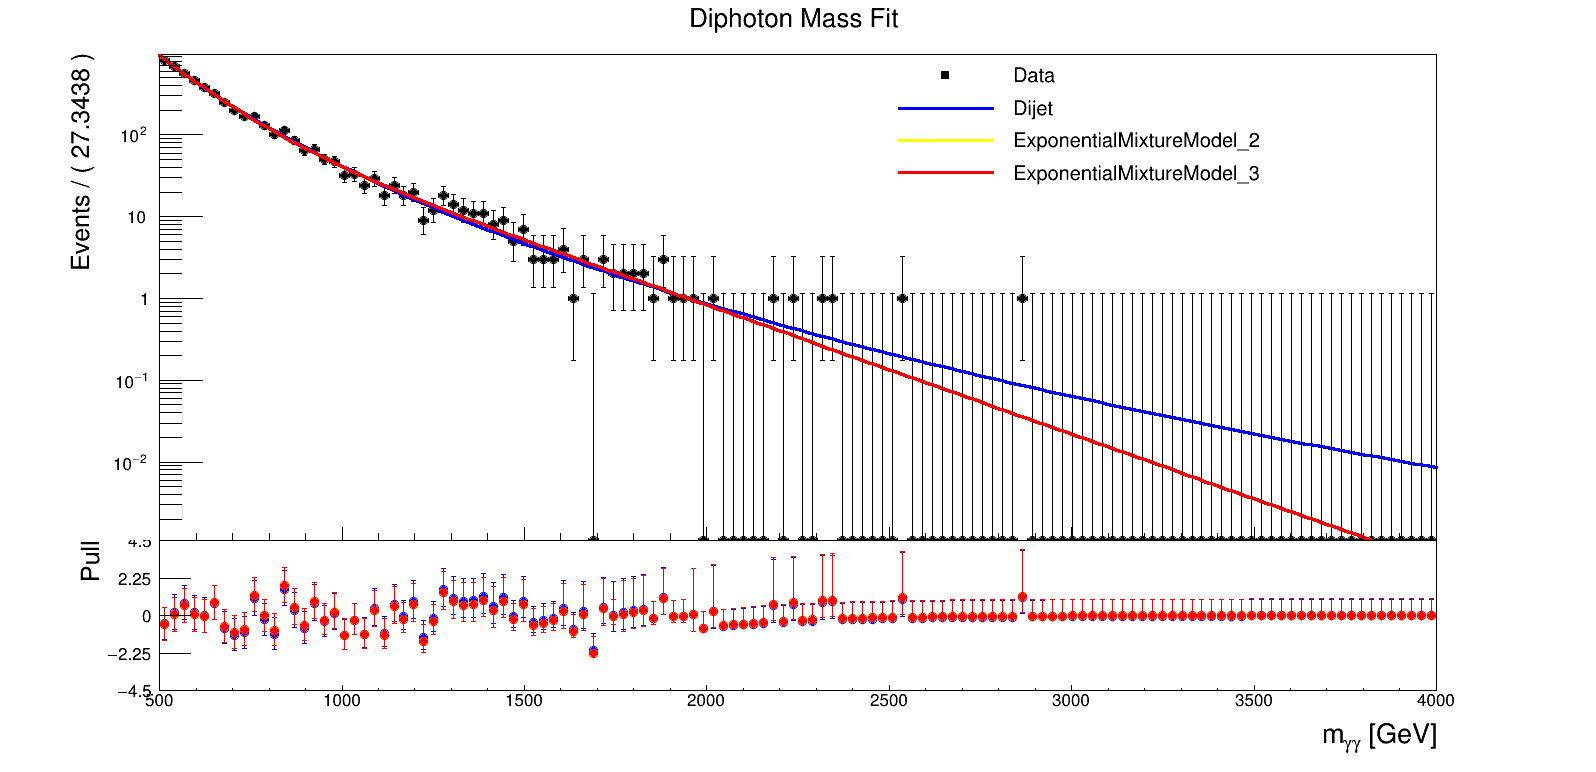

In [13]:
# Plot fits of varying complexity to the signal + background data
models = [emm.Dijet(x)]
models += [emm.ExponentialMixtureModel(x, k, data_mean=data.mean(x)) for k in range(2, 4)]
model_labels = [m.name for m in models]
for m in models:
    m.pdf.fitTo(data, PrintLevel=-1)

emm.plot_fits(data, x, models, model_labels, logx=False)

[#1] INFO:NumericIntegration -- RooRealIntegral::init(Dijet_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_2_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_3_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const o

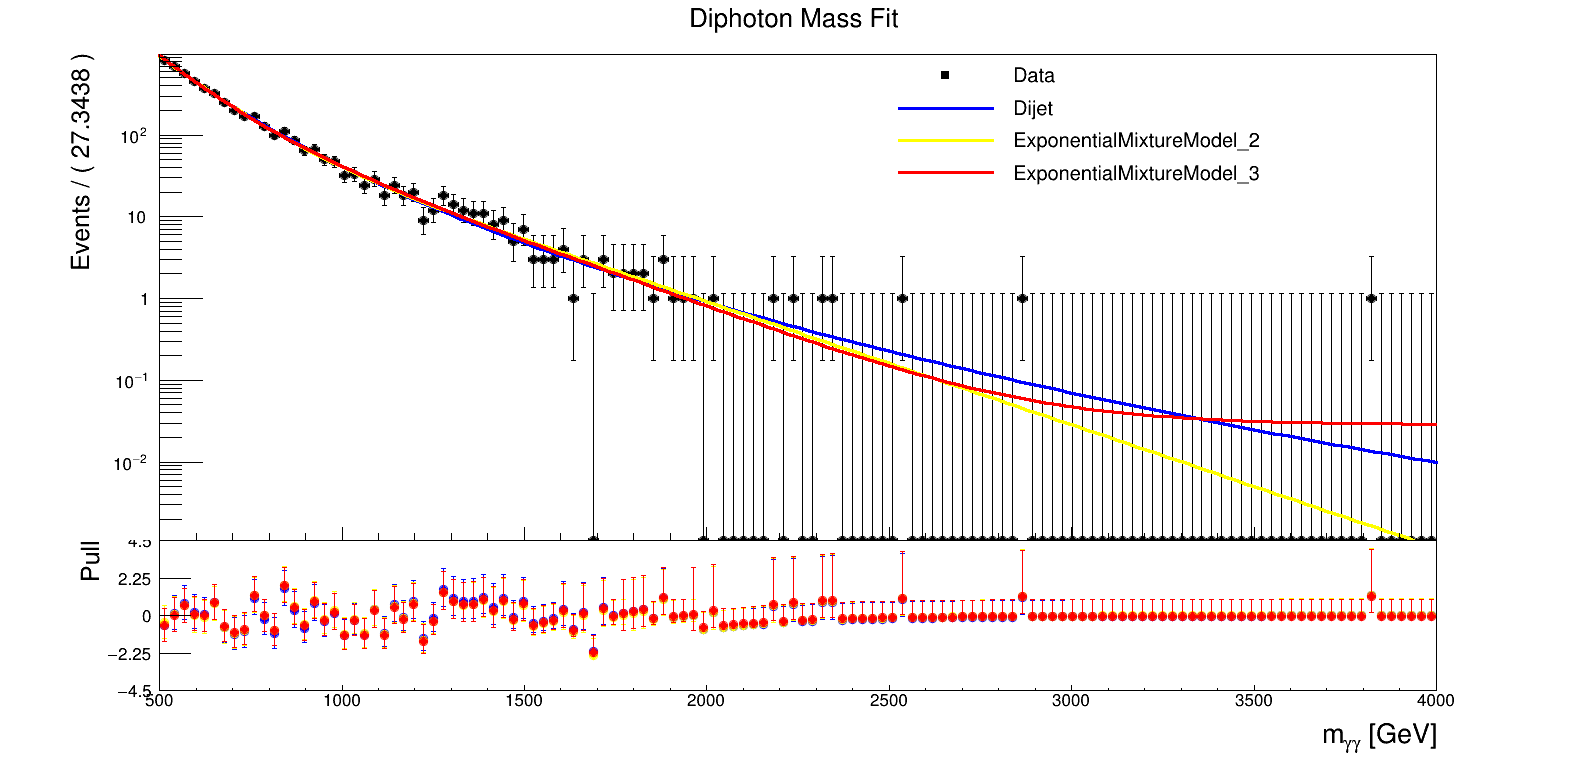